In [2]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_digits
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

In [3]:
digits = load_digits()

X = digits.data
y = digits.target

print("Dataset Shape:", X.shape)

Dataset Shape: (1797, 64)


In [4]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [5]:
pca_full = PCA()

X_pca_full = pca_full.fit_transform(X_scaled)

cumulative_variance = np.cumsum(
    pca_full.explained_variance_ratio_
)


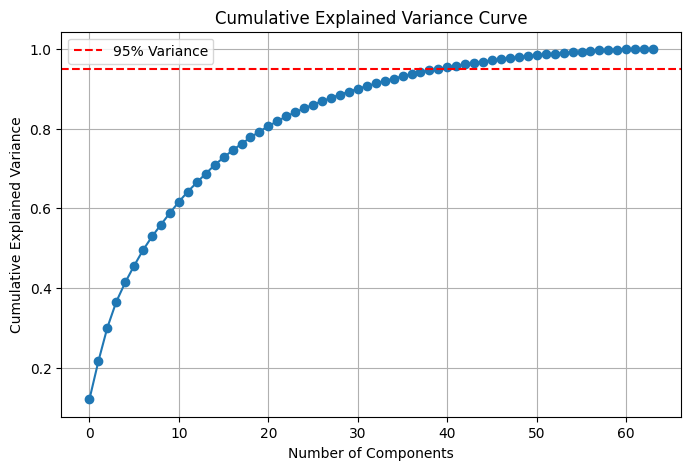

In [6]:
plt.figure(figsize=(8,5))

plt.plot(
    cumulative_variance,
    marker='o'
)

plt.axhline(
    y=0.95,
    color='red',
    linestyle='--',
    label='95% Variance'
)

plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")

plt.title(
    "Cumulative Explained Variance Curve"
)

plt.legend()
plt.grid(True)

plt.show()


In [7]:
n_components_95 = np.argmax(
    cumulative_variance >= 0.95
) + 1

print(
    "Components needed for 95% variance:",
    n_components_95
)


Components needed for 95% variance: 40


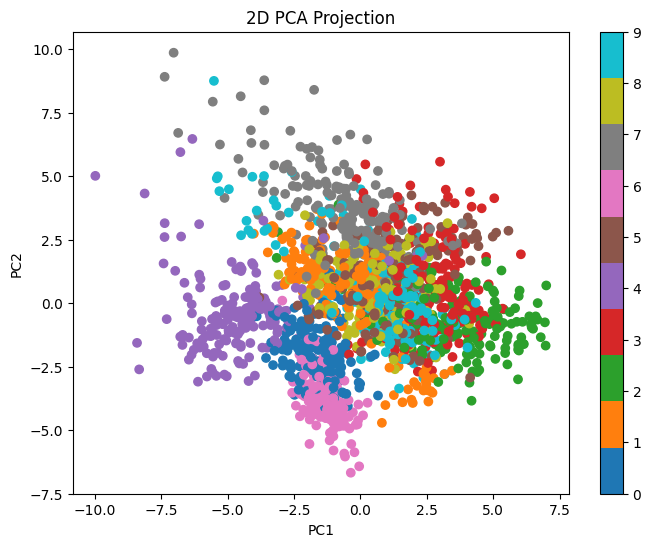

In [8]:
pca_2d = PCA(n_components=2)

X_2d = pca_2d.fit_transform(X_scaled)

plt.figure(figsize=(8,6))

scatter = plt.scatter(
    X_2d[:,0],
    X_2d[:,1],
    c=y,
    cmap='tab10'
)

plt.colorbar(scatter)

plt.title("2D PCA Projection")

plt.xlabel("PC1")
plt.ylabel("PC2")

plt.show()


In [9]:
kmeans_original = KMeans(
    n_clusters=10,
    random_state=42,
    n_init=10
)

labels_original = kmeans_original.fit_predict(
    X_scaled
)

score_original = silhouette_score(
    X_scaled,
    labels_original
)

In [10]:
pca_95 = PCA(
    n_components=n_components_95
)

X_reduced = pca_95.fit_transform(
    X_scaled
)

kmeans_pca = KMeans(
    n_clusters=10,
    random_state=42,
    n_init=10
)

labels_pca = kmeans_pca.fit_predict(
    X_reduced
)

score_pca = silhouette_score(
    X_reduced,
    labels_pca
)

In [11]:
print("\nSilhouette Score Comparison")

print(
    "Without PCA:",
    round(score_original,4)
)

print(
    "With PCA:",
    round(score_pca,4)
)


Silhouette Score Comparison
Without PCA: 0.1394
With PCA: 0.1595


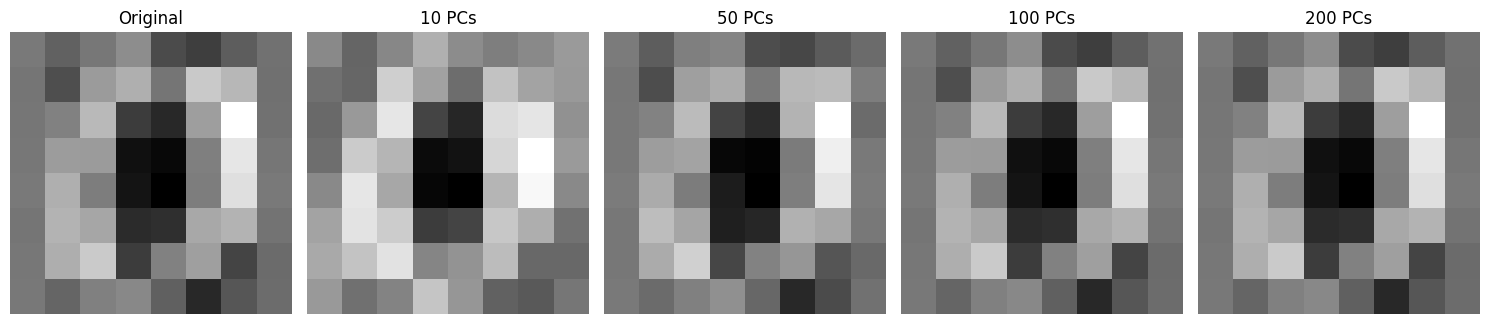

In [12]:
sample_image = X_scaled[0]

components_list = [10, 50, 100, 200]

plt.figure(figsize=(15,4))

# Original Image

plt.subplot(1,5,1)

plt.imshow(
    sample_image.reshape(8,8),
    cmap='gray'
)

plt.title("Original")
plt.axis('off')

# Reconstructions

for i, n in enumerate(components_list):

    pca = PCA(
        n_components=min(n, X_scaled.shape[1])
    )

    X_temp = pca.fit_transform(
        X_scaled
    )

    reconstructed = pca.inverse_transform(
        X_temp
    )

    plt.subplot(1,5,i+2)

    plt.imshow(
        reconstructed[0].reshape(8,8),
        cmap='gray'
    )

    plt.title(f"{n} PCs")

    plt.axis('off')

plt.tight_layout()
plt.show()